# 01 — Exploratory Data Analysis
**CMPE 188 | Flight Delay Prediction**

Goals:
- Understand the raw dataset (shape, types, nulls)
- Assess class balance (Delay 0 vs 1)
- Identify delay patterns by airline, airport, day, and time
- Spot any data quality issues before modeling

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "../data/raw/Airlines.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,1,CO,269,SFO,IAH,3,15,205,1
1,2,US,1558,PHX,CLT,3,15,222,1
2,3,AA,2400,LAX,DFW,3,20,165,1
3,4,AA,2466,SFO,DFW,3,20,195,1
4,5,AS,108,ANC,SEA,3,30,202,0


## 1. Dataset Overview

In [2]:
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nNull counts:")
print(df.isnull().sum())
print()
df.describe()

Shape: (539383, 9)

Dtypes:
id              int64
Airline        object
Flight          int64
AirportFrom    object
AirportTo      object
DayOfWeek       int64
Time            int64
Length          int64
Delay           int64
dtype: object

Null counts:
id             0
Airline        0
Flight         0
AirportFrom    0
AirportTo      0
DayOfWeek      0
Time           0
Length         0
Delay          0
dtype: int64



,id,Flight,DayOfWeek,Time,Length,Delay
count,539383.000000,539383.000000,539383.000000,539383.000000,539383.000000,539383.000000
mean,269692.000000,2427.928630,3.929668,802.728963,132.202007,0.445442
std,155706.604461,2067.429837,1.914664,278.045911,70.117016,0.497015
min,1.000000,1.000000,1.000000,10.000000,0.000000,0.000000
25%,134846.500000,712.000000,2.000000,565.000000,81.000000,0.000000
50%,269692.000000,1809.000000,4.000000,795.000000,115.000000,0.000000
75%,404537.500000,3745.000000,5.000000,1035.000000,162.000000,1.000000
max,539383.000000,7814.000000,7.000000,1439.000000,655.000000,1.000000


## 2. Class Balance

Delay
0    299119
1    240264
Name: count, dtype: int64

Delay rate: 44.5%


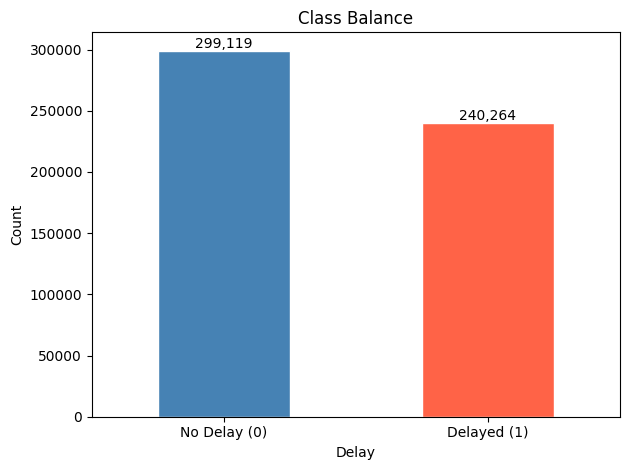

In [3]:
counts = df["Delay"].value_counts().sort_index()
print(counts)
print(f"\nDelay rate: {df['Delay'].mean():.1%}")

ax = counts.plot(kind="bar", color=["steelblue", "tomato"], edgecolor="white")
ax.set_xticklabels(["No Delay (0)", "Delayed (1)"], rotation=0)
ax.set_ylabel("Count")
ax.set_title("Class Balance")
for p in ax.patches:
    ax.annotate(f"{p.get_height():,}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 3. Delay Rate by Category

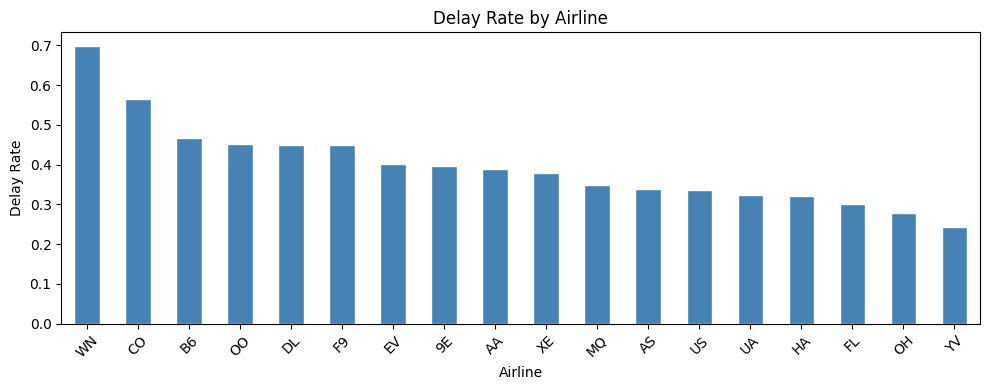

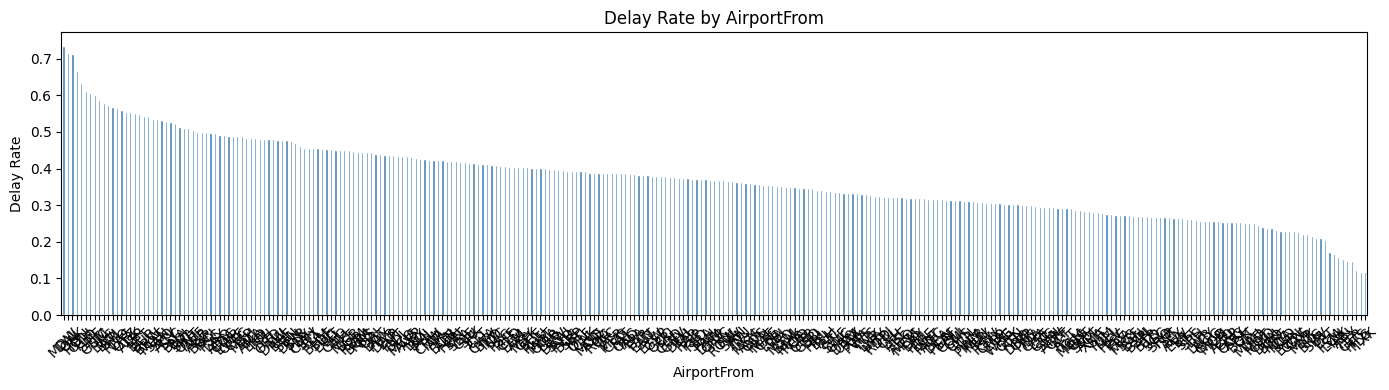

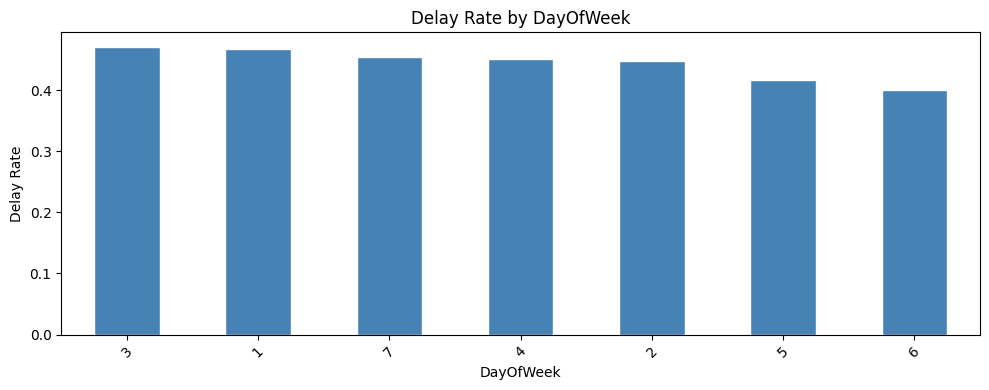

In [4]:
for col in ["Airline", "AirportFrom", "DayOfWeek"]:
    rates = df.groupby(col)["Delay"].mean().sort_values(ascending=False)
    figsize = (14, 4) if col == "AirportFrom" else (10, 4)
    fig, ax = plt.subplots(figsize=figsize)
    rates.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_ylabel("Delay Rate")
    ax.set_title(f"Delay Rate by {col}")
    ax.set_xlabel(col)
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

## 4. Distributions

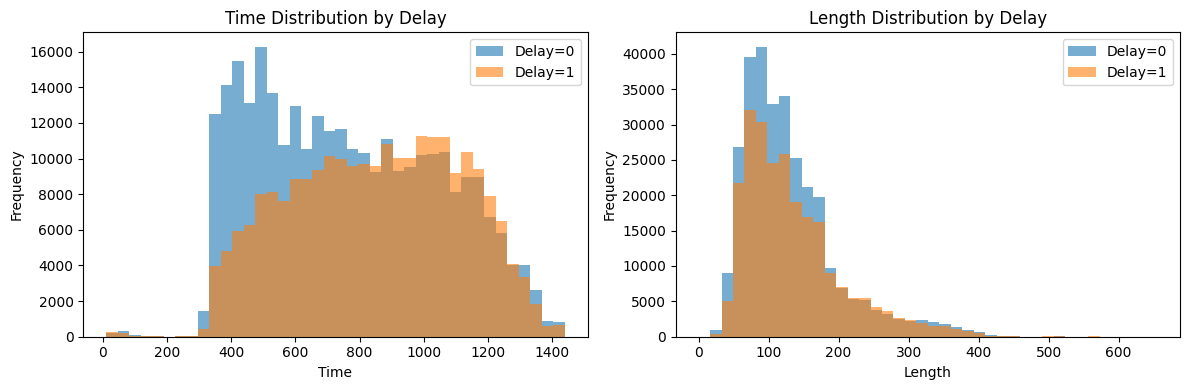

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["Time", "Length"]):
    for label, grp in df.groupby("Delay")[col]:
        grp.plot(kind="hist", bins=40, alpha=0.6, label=f"Delay={label}", ax=ax)
    ax.set_xlabel(col)
    ax.set_title(f"{col} Distribution by Delay")
    ax.legend()
plt.tight_layout()
plt.show()

## 5. Correlation Heatmap

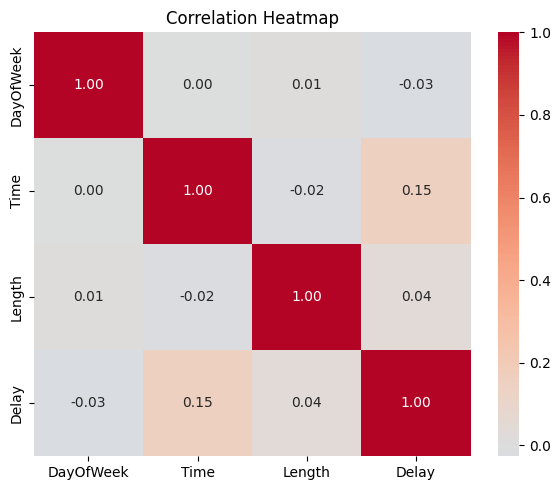

In [6]:
numeric = df[["DayOfWeek", "Time", "Length", "Delay"]]
corr = numeric.corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 6. Key Takeaways

<!-- Fill in after running analysis -->